In [9]:
import os
import time
import pickle
import numpy as np
import pandas as pd

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from xrfm import xrfm
from xrfm.xrfm import xRFM

os.makedirs("results", exist_ok=True)

In [10]:
# fetch dataset
wine = fetch_ucirepo(id=109)

X = wine.data.features
y = wine.data.targets.iloc[:, 0].map({1: 0, 2: 1, 3: 0}).astype(np.float32)

print("Shape", X.shape)
print("Columns", np.unique(y))

Shape (178, 13)
Columns [0. 1.]


## Preprocessing data

In [11]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

<Axes: xlabel='class'>

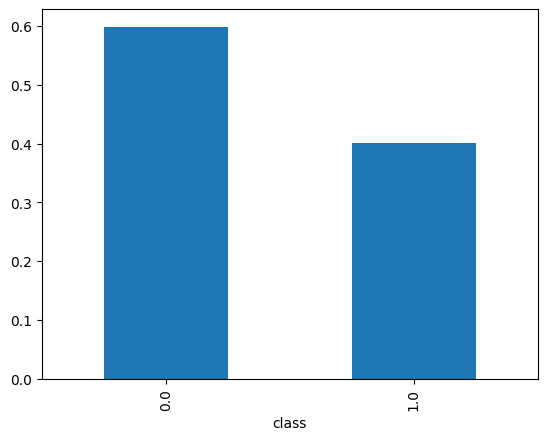

In [12]:
y_train_raw.value_counts(normalize=True).plot(kind='bar')

In [13]:
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)

y_train = y_train_raw.to_numpy().astype(np.float32)
y_test = y_test_raw.to_numpy().astype(np.float32)

In [14]:
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', Pipeline([
#             ('imputer', SimpleImputer(strategy='median')),
#             ('scaler', StandardScaler())
#         ]), num_cols),
#         ('cat', Pipeline([
#             ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
#             ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
#         ]), cat_cols)
#     ]
# )

In [15]:
def evaluate_binary_model(model_name, y_test, y_prob, train_time, infer_time):
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "train_time": train_time,
        "infer_time": infer_time / len(y_test)
    }

In [16]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    eval_metric="logloss"
)

start = time.perf_counter()
xgb_model.fit(X_train, y_train)
train_time = time.perf_counter() - start

start = time.perf_counter()
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
infer_time = time.perf_counter() - start

xgb_results = evaluate_binary_model(
    "XGBoost",
    y_test,
    xgb_prob,
    train_time,
    infer_time
)

pickle.dump(xgb_results, open("results/xgboost.pkl", "wb"))

xgb_results

{'model': 'XGBoost',
 'accuracy': 0.9444444444444444,
 'auc': 0.9967532467532468,
 'train_time': 0.05647370000224328,
 'infer_time': 4.257500000272153e-05}

In [18]:
rfm_params = {
    "model": {
        "kernel": "l2",
        "bandwidth": 3.0,
        "diag": True,
        "bandwidth_mode": "constant",
    },
    "fit": {
        "reg": 1e-3,
        "iters": 2,
        "M_batch_size": 32,
        "verbose": False,
    },
}

xrfm_model = xRFM(
    rfm_params=rfm_params,
    max_leaf_size=100,
    n_tree_iters=1,
    n_trees=1,
    random_state=42,
)

# xRFM workaround
y_train_2d = y_train.reshape(-1, 1)
y_train_2d = np.concatenate([y_train_2d, y_train_2d], axis=1)

start = time.perf_counter()
xrfm_model.fit(X_train, y_train_2d, X_train, y_train_2d)
train_time = time.perf_counter() - start

start = time.perf_counter()
xrfm_prob = np.asarray(xrfm_model.predict(X_test))
infer_time = time.perf_counter() - start

if xrfm_prob.ndim == 2:
    xrfm_prob = xrfm_prob[:, 0]

xrfm_results = evaluate_binary_model(
    "xRFM",
    y_test,
    xrfm_prob,
    train_time,
    infer_time
)

pickle.dump(xrfm_results, open("results/xrfm.pkl", "wb"))

xrfm_results

None
Fitting xRFM with 1 trees and 1 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([134, 13]) y_train torch.Size([134, 2]) X_val torch.Size([8, 13]) y_val torch.Size([8, 2])
Fitting RFM with ntrain: 134, d: 13, and nval: 8
Using cheap batch size
Optimal M batch size: 134
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 68, d: 13, and nval: 88
Time taken for round 0: 0.00412297248840332 seconds
Early stopping at iteration 1
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 68, d: 13, and nval: 88
Time taken for round 0: 0.0019838809967041016 seconds
Time taken for round 1: 0.0029039382934570312 seconds
Using hard routing for tree prediction


Building trees: 100%|██████████| 1/1 [00:00<00:00, 10.01it/s]


Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([134, 13]) y_train torch.Size([134, 2]) X_val torch.Size([8, 13]) y_val torch.Size([8, 2])
Fitting RFM with ntrain: 134, d: 13, and nval: 8
Using cheap batch size
Optimal M batch size: 134
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 68, d: 13, and nval: 88
Time taken for round 0: 0.0 seconds
Early stopping at iteration 1
Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 68, d: 13, and nval: 88
Time taken for round 0: 0.011469125747680664 seconds
Time taken for round 1: 0.001996755599975586 seconds
Using hard routing for tree prediction
==========================Tree iteration results==========================
Validation scores over tree iterations: [0.008212032727897167, 0.005182930268347263]
Best validation score: 0.005182930268347263


Tuning split temperature: 100%|██████████| 36/36 [00:00<00:00, 638.86it/s]

Selected split_temperature=0.0 based on validation mse=0.005183
Using hard routing for tree prediction


{'model': 'xRFM',
 'accuracy': 1.0,
 'auc': 1.0,
 'train_time': 0.16501049999715178,
 'infer_time': 3.1161111110122874e-05}

In [20]:
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


keras.backend.clear_session()

mlp_model = build_mlp(X_train.shape[1])

start = time.perf_counter()
mlp_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0
)
train_time = time.perf_counter() - start

start = time.perf_counter()
mlp_prob = mlp_model.predict(X_test, verbose=0).reshape(-1)
infer_time = time.perf_counter() - start

mlp_results = evaluate_binary_model(
    "MLP",
    y_test,
    mlp_prob,
    train_time,
    infer_time
)

pickle.dump(mlp_results, open("results/mlp.pkl", "wb"))

mlp_results

{'model': 'MLP',
 'accuracy': 1.0,
 'auc': 1.0,
 'train_time': 12.311377999998513,
 'infer_time': 0.0030722583333044895}

xRFM

In [81]:
from hp_script import *
import numpy as np
from xrfm.xrfm import xRFM

def model_builder_xrfm(params):
    # ---- leaf params ----
    bandwidth = params.get("bandwidth", 3.0)
    reg = params.get("reg", 1e-3)
    iters = params.get("iters", 1)
    diag = params.get("diag", True)
    M_batch_size = params.get("M_batch_size", 8)

    # ---- tree params ----
    max_leaf_size = params.get("max_leaf_size", 1000)
    n_tree_iters = params.get("n_tree_iters", 0)

    rfm_params = {
        "model": {
            "kernel": "l2",
            "bandwidth": bandwidth,
            "exponent": 1.0,
            "diag": diag,
            "bandwidth_mode": "constant",
        },
        "fit": {
            "reg": reg,
            "iters": iters,
            "M_batch_size": M_batch_size,
            "verbose": False,
            "early_stop_rfm": True,
        },
    }

    return xRFM(
        rfm_params=rfm_params,
        max_leaf_size=max_leaf_size,
        n_tree_iters=n_tree_iters,
        n_trees=1,
        split_method="top_vector_agop_on_subset",
        tuning_metric='accuracy',
        random_state=42,
    )

def fit_fn_xrfm(model, X_tr, y_tr, X_val, y_val):
    X_tr = np.asarray(X_tr, dtype=np.float32)
    y_tr = np.asarray(y_tr, dtype=np.float32).reshape(-1, 1)
    X_val = np.asarray(X_val, dtype=np.float32)
    y_val = np.asarray(y_val, dtype=np.float32).reshape(-1, 1)

    # 🔥 duplicate target column to satisfy xRFM bug
    y_tr = np.concatenate([y_tr, y_tr], axis=1)
    y_val = np.concatenate([y_val, y_val], axis=1)

    model.fit(X_tr, y_tr, X_val, y_val)
    return model
    
def predict_fn_xrfm(model, X):
    X = np.asarray(X, dtype=np.float32)
    pred = np.asarray(model.predict(X))

    # if model returns duplicated 2-column regression output, take one column
    if pred.ndim == 2:
        return pred[:, 0]

    return pred.reshape(-1)

xrfm_space = {
    "bandwidth": {"type": "float", "low": 0.5, "high": 5.0, "log": True},
    "reg": {"type": "float", "low": 1e-4, "high": 1e-2, "log": True},
    "iters": {"type": "int", "low": 1, "high": 4},
    "diag": {"type": "categorical", "choices": [True]},
    "M_batch_size": {"type": "int", "low": 32, "high": 512},
    "max_leaf_size": {"type": "int", "low": 500, "high": 5000},
    "n_tree_iters": {"type": "int", "low": 1, "high": 3},
}

X_train_processed = X_train
X_test_processed = X_test

results = bayes_tune_model(
    X_train=X_train_processed,
    y_train=np.asarray(y_train, dtype=np.float32),
    X_test=X_test_processed,
    y_test=np.asarray(y_test, dtype=np.float32),
    model_builder=model_builder_xrfm,
    fit_fn=fit_fn_xrfm,
    predict_fn=predict_fn_xrfm,
    param_space=xrfm_space,
    n_trials=20,   # start small; xRFM is expensive
    n_splits=5,    # safer than 5 for this model
)

[I 2026-04-29 11:00:29,429] A new study created in memory with name: no-name-4f82c42e-bc5a-44c6-9852-e3872759f949


None
Fitting xRFM with 1 trees and 1 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 113, d: 13, and nval: 29
Time taken for round 0: 0.0059964656829833984 seconds
Time taken for round 1: 0.005381584167480469 seconds
Time taken for round 2: 0.004014492034912109 seconds
Using hard routing for tree prediction


Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 91, d: 13, and nval: 51
Time taken for round 0: 0.007460832595825195 seconds
Time taken for round 1: 0.004817008972167969 seconds
Time taken for round 2: 0.005723476409912109 seconds
Using hard routing for tree prediction


...


Fitting RFM with ntrain: 92, d: 13, and nval: 50
Time taken for round 0: 0.0013349056243896484 seconds
Time taken for round 1: 0.0 seconds
Time taken for round 2: 0.0 seconds
Using hard routing for tree prediction
==========================Tree iteration results==========================
Validation scores over tree iterations: [1.0, 1.0]
Best validation score: 1.0
Tree has no split, stopping training
Using hard routing for tree prediction
None
Fitting xRFM with 1 trees and 1 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 142, d: 13, and nval: 36
Time taken for round 0: 0.0 seconds
Time taken for round 1: 0.0 seconds
Time taken for round 2: 0.0 seconds
Using hard routing for tree prediction


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Refilling validation set, because at least one split has been made.
Fitting RFM with ntrain: 114, d: 13, and nval: 64
Time taken for round 0: 0.002005338668823242 seconds
Time taken for round 1: 0.0020029544830322266 seconds
Time taken for round 2: 0.0017437934875488281 seconds
Using hard routing for tree prediction
==========================Tree iteration results==========================
Validation scores over tree iterations: [1.0, 1.0]
Best validation score: 1.0
Tree has no split, stopping training
Using hard routing for tree prediction


In [83]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Predict with fitted xRFM
pred = np.asarray(results["best_model"].predict(X_test.astype(np.float32)))

print("Prediction shape:", pred.shape)
print("First 5 predictions:")
print(pred[:5])

# Case 1: xRFM outputs two columns, one score per class
if pred.ndim == 2 and pred.shape[1] == 2:
    y_score = pred[:, 1]
    y_pred = np.argmax(pred, axis=1)

# Case 2: xRFM outputs one column / one score
elif pred.ndim == 2 and pred.shape[1] == 1:
    y_score = pred[:, 0]
    y_pred = (y_score > 0.5).astype(int)

# Case 3: xRFM outputs flat vector
else:
    y_score = pred.ravel()
    y_pred = (y_score > 0.5).astype(int)

# Make sure y_test is 1D
y_test_eval = np.asarray(y_test).astype(int).ravel()

# Evaluate
acc = accuracy_score(y_test_eval, y_pred)
auc = roc_auc_score(y_test_eval, y_score)

print("Accuracy:", acc)
print("ROC AUC:", auc)
print("Confusion matrix:")
print(confusion_matrix(y_test_eval, y_pred))
print("Classification report:")
print(classification_report(y_test_eval, y_pred))

Using hard routing for tree prediction
Prediction shape: (36,)
First 5 predictions:
[0 0 0 0 0]
Accuracy: 0.6111111111111112
ROC AUC: 0.5
Confusion matrix:
[[22  0]
 [14  0]]
Classification report:
              precision    recall  f1-score   support

           0       0.61      1.00      0.76        22
           1       0.00      0.00      0.00        14

    accuracy                           0.61        36
   macro avg       0.31      0.50      0.38        36
weighted avg       0.37      0.61      0.46        36



c:\Users\aadee\OneDrive - UNSW\Documents\Year 3\Term 1\COMP9417\Group Project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aadee\OneDrive - UNSW\Documents\Year 3\Term 1\COMP9417\Group Project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aadee\OneDrive - UNSW\Documents\Year 3\Term 1\COMP9417\Group Project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

y_pred_proba = results['best_model'].predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)
roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test ROC AUC: {roc_auc:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Using hard routing for tree prediction
Test ROC AUC: 0.5000
Test Accuracy: 0.6111


MLP

In [58]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from hp_script import *

In [59]:
def model_builder_keras(params, input_dim=None):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for _ in range(params["num_layers"]):
        model.add(layers.Dense(params["hidden_dim"], activation=params["activation"]))
        if params["dropout"] > 0:
            model.add(layers.Dropout(params["dropout"]))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params["lr"]),
        loss="BinaryCrossentropy"
    )
    return model

def make_keras_builder(input_dim):
    def builder(params):
        return model_builder_keras(params, input_dim=input_dim)
    return builder

def fit_fn_keras(model, X_tr, y_tr, X_val, y_val):
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True
    )

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )
    return model

def predict_fn_keras(model, X):
    return model.predict(X, verbose=0).reshape(-1)

keras_space = {
    "hidden_dim": {"type": "int", "low": 32, "high": 256},
    "num_layers": {"type": "int", "low": 1, "high": 4},
    "dropout": {"type": "float", "low": 0.0, "high": 0.5},
    "lr": {"type": "float", "low": 1e-4, "high": 1e-2, "log": True},
    "activation": {"type": "categorical", "choices": ["relu", "tanh"]},
}

builder = make_keras_builder(input_dim=X_train.shape[1])

results = bayes_tune_model(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_builder=builder,
    fit_fn=fit_fn_keras,
    predict_fn=predict_fn_keras,
    param_space=keras_space,
    n_trials=20,
    n_splits=5,
)

[I 2026-04-29 10:15:40,089] A new study created in memory with name: no-name-0af9e515-46e6-4dc9-ae0a-37a76eeb1c1a
[I 2026-04-29 10:16:06,988] Trial 0 finished with value: 1.1803820133209229 and parameters: {'hidden_dim': 116, 'num_layers': 4, 'dropout': 0.36599697090570255, 'lr': 0.0015751320499779737, 'activation': 'relu'}. Best is trial 0 with value: 1.1803820133209229.
[I 2026-04-29 10:16:34,781] Trial 1 finished with value: 1.6634384393692017 and parameters: {'hidden_dim': 45, 'num_layers': 4, 'dropout': 0.3005575058716044, 'lr': 0.0026070247583707684, 'activation': 'tanh'}. Best is trial 0 with value: 1.1803820133209229.
[I 2026-04-29 10:18:04,792] Trial 2 finished with value: 0.7755762934684753 and parameters: {'hidden_dim': 219, 'num_layers': 1, 'dropout': 0.09091248360355031, 'lr': 0.00023270677083837802, 'activation': 'tanh'}. Best is trial 2 with value: 0.7755762934684753.
[I 2026-04-29 10:19:10,716] Trial 3 finished with value: 1.240605115890503 and parameters: {'hidden_dim'

In [60]:
results

{'best_params': {'hidden_dim': 58,
  'num_layers': 3,
  'dropout': 0.2116748483925655,
  'lr': 0.00015171197459113198,
  'activation': 'relu'},
 'best_cv_score': 0.4434437155723572,
 'best_model': <Sequential name=sequential_201, built=True>,
 'test_rmse': np.float32(0.84367234),
 'test_r2': np.float32(-1.9950349),
 'test_predictions': array([-0.6994703 , -0.85661626, -0.28798035, -0.77065796,  1.8330085 ,
        -1.4841107 ,  1.588967  , -0.70633805,  1.157812  , -0.40449694,
        -0.374194  , -1.0651431 , -0.11559618,  0.7090524 , -1.5020306 ,
         1.6556063 ,  1.7384747 ,  1.6544961 , -0.9259586 ,  1.8152319 ,
        -1.9250504 ,  1.3225156 ,  0.5942928 , -1.130325  , -0.62064946,
        -0.773819  ,  1.8439151 ,  0.4232752 ,  1.0287299 , -0.61189854,
        -0.6636417 ,  2.1332264 , -0.34630635, -1.09738   , -1.1173362 ,
        -1.1339936 ], dtype=float32),
 'preprocess_artifact': None}

In [65]:
from sklearn.metrics import roc_auc_score, accuracy_score

y_pred_proba = results['best_model'].predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)
roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)

print("ROC-AUC:", roc_auc)
print("Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
ROC-AUC: 1.0
Accuracy: 0.9722222222222222


In [39]:
with open('results/xgboost.pkl', 'rb') as f:
    xrfm_results = pickle.load(f)
xrfm_results

{'best_params': {'n_estimators': 822,
  'max_depth': 5,
  'learning_rate': 0.025912478883543956,
  'subsample': 0.6333815393157022,
  'colsample_bytree': 0.7889287846668805,
  'min_child_weight': 5,
  'reg_alpha': 0.1101632409448572,
  'reg_lambda': 0.048671709468502716},
 'best_cv_score': 0.4538925029976908,
 'best_model': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.7889287846668805, device=None,
               early_stopping_rounds=25, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.025912478883543956,
               max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=5, missing=nan, monot

In [ ]:
def htuning(model, search_spaces):
    preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)
    # ----------------------------
    # 2. Full pipeline
    # ----------------------------
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # ----------------------------
    # 3. K-fold CV
    # ----------------------------
    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # ----------------------------
    # 5. Bayesian search
    # ----------------------------
    opt = BayesSearchCV(
        estimator=pipe,
        search_spaces=search_spaces,
        n_iter=32,   # a bit leaner and more efficient
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=1,
        random_state=42,
        verbose=1,
        refit=True
    )

    # ----------------------------
    # 6. Fit
    # ----------------------------
    opt.fit(X_train, y_train)

    print("Best CV RMSE:", -opt.best_score_)
    print("Best params:")
    for k, v in opt.best_params_.items():
        print(f"{k}: {v}")

    best_model = opt.best_estimator_

    # ----------------------------
    # 7. Test evaluation
    # ----------------------------
    y_pred = best_model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    print("\nTest RMSE:", rmse)
    print("Test R^2:", r2)

In [ ]:

xrfm = SklearnXRFMRegressor(
    tuning_metric=None,
    split_method='top_vector_agop_on_subset',
    verbose=False,
    random_state=42
)

xrfm_search_spaces = {
    'model__bandwidth': Real(0.5, 10.0, prior='log-uniform'),
    'model__reg': Real(1e-4, 1e-1, prior='log-uniform'),
    'model__iters': Integer(1, 2),
    'model__diag': Categorical([True]),
    'model__M_batch_size': Categorical([4, 8, 16, 32]),

    'model__max_leaf_size': Categorical([2000]),
    'model__n_tree_iters': Integer(1, 10),
}

htuning(xrfm, xrfm_search_spaces)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
None
Fitting xRFM with 1 trees and 5 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 876, d: 312, and nval: 876


Building trees:   0%|          | 0/1 [00:11<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
xrfm = xRFM(
    tuning_metric='mse',
    split_method='top_vector_agop_on_subset',
    verbose=False,
    random_state=42
)
Xt = preprocessor.fit_transform(X_train)
xrfm.fit(Xt, y_train.to_numpy(), Xt, y_train.to_numpy())

None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 1095, d: 314, and nval: 1095
Using cheap batch size
Optimal M batch size: 1095
Time taken for round 0: 0.04700350761413574 seconds
Using cheap batch size
Optimal M batch size: 1095
Time taken for round 1: 0.05451774597167969 seconds
Using cheap batch size
Optimal M batch size: 1095
Time taken for round 2: 0.03699970245361328 seconds
Using cheap batch size
Optimal M batch size: 1095
Time taken for round 3: 0.03299903869628906 seconds
Using cheap batch size

Building trees:   0%|          | 0/1 [00:00<?, ?it/s]


Optimal M batch size: 1095
Time taken for round 4: 0.029525279998779297 seconds
Using cheap batch size
Optimal M batch size: 1095
Tree has no split, stopping training


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

xtest = preprocessor.transform(X_test).astype(np.float32)
y_pred = xrfm.predict(xtest)
y_true = y_test.to_numpy().ravel()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

Using hard routing for tree prediction
RMSE: 29624.18255412291
R2: 0.8747246861457825


In [ ]:
xrfm = SklearnXRFMRegressor(
    tuning_metric=None,
    split_method='top_vector_agop_on_subset',
    verbose=False,
    random_state=42
)
Xt = preprocessor.fit_transform(X_train)
xrfm.fit(Xt, y_train.to_numpy())

None
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting RFM with ntrain: 1095, d: 314, and nval: 1095


Building trees:   0%|          | 0/1 [00:34<?, ?it/s]


RuntimeError: [enforce fail at alloc_cpu.cpp:117] data. DefaultCPUAllocator: not enough memory: you tried to allocate 935721256000 bytes.

In [ ]:
xgbr_search_spaces = {
    'model__n_estimators': Integer(200, 1200),
    'model__max_depth': Integer(3, 8),
    'model__learning_rate': Real(0.01, 0.15, prior='log-uniform'),
    'model__subsample': Real(0.65, 1.0),
    'model__colsample_bytree': Real(0.65, 1.0),
    'model__min_child_weight': Integer(1, 12),
    'model__gamma': Real(1e-8, 2.0, prior='log-uniform'),
    'model__reg_alpha': Real(1e-8, 2.0, prior='log-uniform'),
    'model__reg_lambda': Real(1e-6, 20.0, prior='log-uniform')
}
xgbr = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'   # usually faster on tabular data
    )
xrfm = xRFM(
    tuning_metric='mse',     # Tuning metric
    split_method='top_vector_agop_on_subset'  # Splitting strategy
)
xrfm_search_spaces = {
    # ----- Leaf RFM params -----
    'model__rfm_params__model__bandwidth': Real(0.5, 20.0, prior='log-uniform'),
    'model__rfm_params__fit__reg': Real(1e-5, 1e-1, prior='log-uniform'),
    'model__rfm_params__fit__iters': Integer(2, 6),
    'model__rfm_params__model__diag': Categorical([False, True]),
    'model__rfm_params__fit__M_batch_size': Categorical([512, 1024, 2048]),

    # ----- xRFM tree params -----
    'model__max_leaf_size': Integer(5000, 50000),
    'model__n_trees': Integer(1, 4),
    'model__n_tree_iters': Integer(0, 3),
}
htuning(xrfm, xrfm_search_spaces)

None
Fitting 5 folds for each of 1 candidates, totalling 5 fits


AttributeError: 'xRFM' object has no attribute 'set_params'

In [ ]:
# ----------------------------
# 1. Your preprocessing
# ----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

# ----------------------------
# 2. Full pipeline
# ----------------------------
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'   # usually faster on tabular data
    ))
])

# ----------------------------
# 3. K-fold CV
# ----------------------------
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ----------------------------
# 4. Bayesian search space
# ----------------------------
search_spaces = {

    # Focused XGBoost ranges
    'model__n_estimators': Integer(200, 1200),
    'model__max_depth': Integer(3, 8),
    'model__learning_rate': Real(0.01, 0.15, prior='log-uniform'),
    'model__subsample': Real(0.65, 1.0),
    'model__colsample_bytree': Real(0.65, 1.0),
    'model__min_child_weight': Integer(1, 12),
    'model__gamma': Real(1e-8, 2.0, prior='log-uniform'),
    'model__reg_alpha': Real(1e-8, 2.0, prior='log-uniform'),
    'model__reg_lambda': Real(1e-6, 20.0, prior='log-uniform')
}

# ----------------------------
# 5. Bayesian search
# ----------------------------
opt = BayesSearchCV(
    estimator=pipe,
    search_spaces=search_spaces,
    n_iter=32,   # a bit leaner and more efficient
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True
)

# ----------------------------
# 6. Fit
# ----------------------------
opt.fit(X_train, y_train)

print("Best CV RMSE:", -opt.best_score_)
print("Best params:")
for k, v in opt.best_params_.items():
    print(f"{k}: {v}")

best_model = opt.best_estimator_

# ----------------------------
# 7. Test evaluation
# ----------------------------
y_pred = best_model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nTest RMSE:", rmse)
print("Test R^2:", r2)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi